# Baseline BKT Model

## Overview

This notebook establishes a **baseline Bayesian Knowledge Tracing (BKT)** model for tracking
skill mastery in learners with autism spectrum disorder (ASD). It uses the standard
4-parameter BKT formulation as a reproducible performance reference point.

---

### Bayesian Knowledge Tracing Background

BKT is a Hidden Markov Model that estimates whether a learner has mastered a skill
based on their response history. At each practice opportunity the model updates a
belief over two latent states: **unlearned** and **learned**.

The four core parameters are:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Prior     | P(L₀)  | Probability the skill is already mastered before any practice |
| Learn     | P(T)   | Probability of transitioning from unlearned → learned after one opportunity |
| Guess     | P(G)   | Probability of a correct response despite **not** knowing the skill |
| Slip      | P(S)   | Probability of an incorrect response despite **knowing** the skill |

---

### Notebook Objectives

1. Load and validate the synthetic learning trajectory dataset
2. Reformat data into the column layout expected by pyBKT
3. Perform a **student-level** train/test split to prevent data leakage
4. Train the baseline BKT model with fixed emission parameters for stability
5. Inspect the learned parameters for each skill
6. Evaluate model performance (Accuracy, RMSE, AUC) on both splits
7. Persist the model and results for downstream comparison

---

## 1. Environment Setup

In [44]:
# ================================================
# Import Required Libraries
# ================================================

# Core data manipulation
import pandas as pd
import numpy as np
from pathlib import Path
from importlib import metadata

# Shared BKT engine and split helper
from src.bkt_engine import (
    PARAM_SCHEMA,
    bkt_predict_sequence,
    fit_bkt_skill,
    get_prediction_column,
    predict_by_skill,
)
from src.split_utils import student_level_split

# Data splitting and evaluation
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    mean_squared_error,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence
import pickle
import json
from datetime import datetime
import warnings

# Configure environment
warnings.filterwarnings('ignore')
np.random.seed(42)  # Reproducibility
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)


def _package_version(name: str) -> str:
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return 'not installed'

print('✓ All dependencies loaded')
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print('Library versions:')
print(f"  pyBKT   : {_package_version('pyBKT')}")
print(f"  sklearn : {_package_version('scikit-learn')}")
print(f"  numpy   : {_package_version('numpy')}")
print(f"  pandas  : {_package_version('pandas')}")


✓ All dependencies imported successfully
Timestamp: 2026-04-24 19:55:54


In [45]:
# ── Project directory layout ──────────────────────────────────────────────────
# Resolve the project root dynamically so the notebook works on any machine and
# from any launch directory inside VS Code.
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "raw").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()

DATA_RAW    = PROJECT_ROOT / "data/raw"
DATA_PROC   = PROJECT_ROOT / "data/processed"
MODELS_DIR  = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Create output directories if they do not yet exist
for directory in [DATA_PROC, MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✓ Directory structure ready")
for label, path in [("Raw data", DATA_RAW), ("Models", MODELS_DIR),
                    ("Results", RESULTS_DIR), ("Figures", FIGURES_DIR)]:
    print(f"  {label}: {path}")

✓ Directory structure ready
  Raw data: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\data\raw
  Models: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\models
  Results: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results
  Figures: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures


## 2. Data Loading and Preparation

In [46]:
# ── Load the synthetic autism learning trajectory dataset ─────────────────────
# Expected columns:
#   anon_student_id  – anonymised learner identifier
#   skill_name       – name of the skill being practiced
#   correct          – binary response (1 = correct, 0 = incorrect)
#   hint_used        – whether a hint was requested (1 = yes)
#   behavior_score   – engagement / behaviour proxy score
#   opportunity      – sequential attempt number within a skill for this learner
#   p_l_hat          – ground-truth latent mastery probability (from simulator)

data_path = DATA_RAW / "synthetic_autism_data.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Data file not found: {data_path}")

df_raw = pd.read_csv(data_path)

print("✓ Data loaded successfully")
print(f"  Records : {len(df_raw):,}")
print(f"  Columns : {df_raw.columns.tolist()}")
print("\nFirst 10 rows:")
display(df_raw.head(10))

✓ Data loaded successfully
  Records : 864,000
  Columns : ['anon_student_id', 'skill_name', 'correct', 'hint_used', 'behavior_score', 'opportunity', 'p_l_hat']

First 10 rows:


,anon_student_id,skill_name,correct,hint_used,behavior_score,opportunity,p_l_hat
0,0,counting,0,1,0.75200,1,0.11020
1,0,counting,1,0,0.97100,2,0.68140
2,0,counting,0,0,0.64300,3,0.29190
3,0,counting,0,0,0.80500,4,0.08800
4,0,counting,0,0,0.78400,5,0.04610
5,0,counting,0,1,0.88800,6,0.03890
6,0,counting,0,1,0.73400,7,0.04670
7,0,counting,0,1,1.00000,8,0.04120
8,0,counting,1,0,0.94500,9,0.63980
9,0,counting,1,0,0.92400,10,0.92390


In [47]:
# ── Data quality checks ───────────────────────────────────────────────────────
print("=" * 70)
print("DATA VALIDATION REPORT")
print("=" * 70)

# 1. Missing values
missing = df_raw.isnull().sum()
print("\n1. Missing Values:")
if missing.sum() == 0:
    print("   ✓ No missing values detected")
else:
    print("   ⚠ Missing values found:")
    for col, count in missing[missing > 0].items():
        print(f"     {col}: {count} ({count / len(df_raw):.2%})")

# 2. Column dtypes
print("\n2. Data Types:")
for col, dtype in df_raw.dtypes.items():
    print(f"   {col}: {dtype}")

# 3. High-level dataset statistics
n_students    = df_raw["anon_student_id"].nunique()
n_skills      = df_raw["skill_name"].nunique()
avg_attempts  = df_raw.groupby("anon_student_id").size().mean()
overall_acc   = df_raw["correct"].mean()

print("\n3. Dataset Statistics:")
print(f"   Students              : {n_students}")
print(f"   Skills                : {n_skills}")
print(f"   Avg attempts/student  : {avg_attempts:.1f}")
print(f"   Overall accuracy      : {overall_acc:.2%}")

# 4. Skill distribution
print("\n4. Skill Distribution:")
for skill, count in df_raw["skill_name"].value_counts().items():
    print(f"   {skill}: {count:,} attempts ({count / len(df_raw):.1%})")

# 5. Hint and mastery sanity checks
print("\n5. Behavioural signal checks:")
print(f"   Mean hint_used      : {df_raw['hint_used'].mean():.3f}")
print(f"   Mean p_l_hat        : {df_raw['p_l_hat'].mean():.3f}")
print(f"   p_l_hat range       : [{df_raw['p_l_hat'].min():.3f}, {df_raw['p_l_hat'].max():.3f}]")

DATA VALIDATION REPORT

1. Missing Values:
   ✓ No missing values detected

2. Data Types:
   anon_student_id: int64
   skill_name: object
   correct: int64
   hint_used: int64
   behavior_score: float64
   opportunity: int64
   p_l_hat: float64

3. Dataset Statistics:
   Students              : 1200
   Skills                : 6
   Avg attempts/student  : 720.0
   Overall accuracy      : 79.58%

4. Skill Distribution:
   counting: 144,000 attempts (16.7%)
   shape_recognition: 144,000 attempts (16.7%)
   addition: 144,000 attempts (16.7%)
   subtraction: 144,000 attempts (16.7%)
   multiplication: 144,000 attempts (16.7%)
   division: 144,000 attempts (16.7%)

5. Behavioural signal checks:
   Mean hint_used      : 0.218
   Mean p_l_hat        : 0.917
   p_l_hat range       : [0.006, 0.999]


In [48]:
# ── Reformat data for pyBKT ───────────────────────────────────────────────────
# pyBKT's Model.fit() requires at minimum these four column names:
#   user_id    – learner identifier
#   skill_name – skill being practiced
#   correct    – binary response (0 or 1)
#   order_id   – integer that preserves temporal ordering within each learner
#
# We retain behavior_score and hint_used for downstream analysis in notebook 04.
# We also keep p_l_hat so we can compare the fitted mastery estimates against the
# simulator's ground-truth latent knowledge trajectory after prediction.
df_bkt = (
    df_raw
    .rename(columns={"anon_student_id": "user_id",
                     "opportunity":      "order_id"})
    [["user_id", "skill_name", "correct", "order_id", "behavior_score", "hint_used", "p_l_hat"]]
    .copy()
)

# Ensure 'correct' is stored as a proper integer (pyBKT expectation)
df_bkt["correct"] = df_bkt["correct"].astype(int)

# Guard: raise an error early if any expected column is missing
required_cols = ["user_id", "skill_name", "correct", "order_id"]
missing_cols  = [c for c in required_cols if c not in df_bkt.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("✓ Data formatted for pyBKT")
print(f"  Shape   : {df_bkt.shape}")
print(f"  Columns : {df_bkt.columns.tolist()}")
print("\nSample rows:")
display(df_bkt.head())

✓ Data formatted for pyBKT
  Shape   : (864000, 7)
  Columns : ['user_id', 'skill_name', 'correct', 'order_id', 'behavior_score', 'hint_used', 'p_l_hat']

Sample rows:


,user_id,skill_name,correct,order_id,behavior_score,hint_used,p_l_hat
0,0,counting,0,1,0.75200,1,0.11020
1,0,counting,1,2,0.97100,0,0.68140
2,0,counting,0,3,0.64300,0,0.29190
3,0,counting,0,4,0.80500,0,0.08800
4,0,counting,0,5,0.78400,0,0.04610


In [49]:
# ── EDA validation: learning-curve direction and hint informativeness ─────────
# These checks help confirm that the synthetic dataset carries the behavioural signal
# the dissertation claims to study.

print("=" * 70)
print("SKILL LEARNING CURVE VALIDATION")
print("=" * 70)

for skill in sorted(df_bkt["skill_name"].unique()):
    skill_df = df_bkt[df_bkt["skill_name"] == skill].sort_values("order_id")
    curve = skill_df.groupby("order_id")["correct"].mean()

    if len(curve) < 3:
        print(f"  {skill:<20} insufficient opportunities for a learning-curve check")
        continue

    third = max(len(curve) // 3, 1)
    early_acc = curve.iloc[:third].mean()
    late_acc = curve.iloc[-third:].mean()
    direction = "✓ PASS ↑" if late_acc > early_acc else "⚠ WARN ↓"
    print(f"  {skill:<20} early={early_acc:.3f}  late={late_acc:.3f}  {direction}")

print("\n" + "=" * 70)
print("HINT INFORMATIVENESS CHECK")
print("=" * 70)

overall_hint_corr = df_bkt["hint_used"].corr(df_bkt["correct"])
hint_means = df_bkt.groupby("hint_used")["correct"].agg(["mean", "count"]).rename(index={0: "no_hint", 1: "hint"})
per_skill_hint_corr = (
    df_bkt.groupby("skill_name")
    .apply(lambda x: x["hint_used"].corr(x["correct"]))
    .rename("hint_correct_corr")
    .sort_values(ascending=True)
)

print(f"Overall hint/correct correlation: {overall_hint_corr:.4f}")
print("\nCorrect rate by hint usage:")
print(hint_means.to_string())
print("\nPer-skill hint/correct correlation:")
print(per_skill_hint_corr.to_string())

if overall_hint_corr < 0:
    print("\nInterpretation: hints are associated with lower correctness, so they carry predictive signal.")
elif overall_hint_corr > 0:
    print("\nInterpretation: hints are associated with higher correctness in this synthetic sample.")
else:
    print("\nInterpretation: hints appear uninformative in this synthetic sample.")

SKILL LEARNING CURVE VALIDATION


  addition             early=0.781  late=0.822  ✓ PASS ↑
  counting             early=0.784  late=0.825  ✓ PASS ↑
  division             early=0.744  late=0.797  ✓ PASS ↑
  multiplication       early=0.748  late=0.804  ✓ PASS ↑
  shape_recognition    early=0.776  late=0.821  ✓ PASS ↑
  subtraction          early=0.744  late=0.805  ✓ PASS ↑

HINT INFORMATIVENESS CHECK
Overall hint/correct correlation: -0.0397

Correct rate by hint usage:
             mean   count
hint_used                
no_hint   0.80425  676005
hint      0.76543  187995

Per-skill hint/correct correlation:
skill_name
subtraction         -0.05389
division            -0.05051
multiplication      -0.04530
addition            -0.03156
counting            -0.02660
shape_recognition   -0.02617

Interpretation: hints are associated with lower correctness, so they carry predictive signal.


## 3. Train–Test Split

We split at the **student level**: every row belonging to a given student goes
entirely into either the training set or the test set.  This mirrors real-world
deployment, where the model must generalise to learners it has never seen, and
prevents any label leakage that would arise from row-level splitting.

In [50]:
# ── Configuration ─────────────────────────────────────────────────────────────
TEST_SIZE   = 0.20  # fraction of students held out for testing
RANDOM_SEED = 42    # seed for reproducibility

# ── Student-level split ───────────────────────────────────────────────────────
train_df, test_df, train_students, test_students = student_level_split(
    df_bkt,
    student_col='user_id',
    test_size=TEST_SIZE,
    seed=RANDOM_SEED,
)

train_df = train_df.sort_values(['user_id', 'skill_name', 'order_id']).reset_index(drop=True)
test_df = test_df.sort_values(['user_id', 'skill_name', 'order_id']).reset_index(drop=True)
n_total = df_bkt['user_id'].nunique()

# Enforce a small-sample guard per skill so the baseline does not fit unstable
# parameters on tiny groups. The thresholds are deliberately lower than notebook 02b
# because the ASD dataset is much smaller.
MIN_STUDENTS_PER_SKILL = 10
MIN_MEAN_OPPS = 3
skill_stats = (
    train_df.groupby('skill_name')
    .agg(
        n_students=('user_id', 'nunique'),
        n_rows=('order_id', 'size'),
    )
    .assign(mean_opps=lambda x: x['n_rows'] / x['n_students'])
)
eligible_skills = skill_stats[
    (skill_stats['n_students'] >= MIN_STUDENTS_PER_SKILL) &
    (skill_stats['mean_opps'] >= MIN_MEAN_OPPS)
].index.tolist()

if not eligible_skills:
    raise ValueError('No skills satisfy the minimum sample-size filter.')

train_df = train_df[train_df['skill_name'].isin(eligible_skills)].reset_index(drop=True)
test_df = test_df[test_df['skill_name'].isin(eligible_skills)].reset_index(drop=True)

# ── Verification ──────────────────────────────────────────────────────────────
overlap = set(train_students) & set(test_students)

print('=' * 70)
print('TRAIN–TEST SPLIT SUMMARY')
print('=' * 70)
print()
print(f'Total students : {n_total}')
print()
print('Training Set')
print(f"  Students : {len(train_students)} ({len(train_students)/n_total:.1%})")
print(f"  Records  : {len(train_df):,}")
print(f"  Accuracy : {train_df['correct'].mean():.2%}")
print()
print('Test Set')
print(f"  Students : {len(test_students)} ({len(test_students)/n_total:.1%})")
print(f"  Records  : {len(test_df):,}")
print(f"  Accuracy : {test_df['correct'].mean():.2%}")
print()
print(f'Skills retained after sample-size filter: {len(eligible_skills)}')
print(skill_stats.loc[eligible_skills].sort_values('n_students', ascending=False).head(10).to_string())
print()
if len(overlap) == 0:
    print('✓ No student overlap – split is clean')
else:
    print(f'⚠ WARNING: {len(overlap)} students appear in both sets!')


TRAIN–TEST SPLIT SUMMARY

Total students : 1200

Training Set
  Students : 960 (80.0%)
  Records  : 691,200
  Accuracy : 79.55%

Test Set
  Students : 240 (20.0%)
  Records  : 172,800
  Accuracy : 79.71%

Skills retained after sample-size filter: 6
                   n_students  n_rows  mean_opps
skill_name                                      
addition                  960  115200  120.00000
counting                  960  115200  120.00000
division                  960  115200  120.00000
multiplication            960  115200  120.00000
shape_recognition         960  115200  120.00000
subtraction               960  115200  120.00000

✓ No student overlap – split is clean


# ================================================
# Train BKT Model with Forgetting
# ================================================

# Initialize BKT model with forgetting enabled
# This adds the 5th parameter: P(F) - probability of forgetting
model_with_forgetting = Model(
    seed=RANDOM_SEED,
    num_fits=5  # Multiple random initializations for robustness
)

print('Training BKT with forgetting parameter...')
print(f"  - Training on {len(train_df):,} records")
print(f"  - Students: {len(train_students)}")
print(f"  - Skills: {train_df['skill_name'].nunique()}")
print()

# Prepare training data in BKT format (user_id, skill_name, correct)
train_bkt_format = train_df[['user_id', 'skill_name', 'correct']].copy()

# Fit model with forgetting
# Note: pyBKT's Model class supports forgetting through the forgets parameter
model_with_forgetting.fit(
    data=train_bkt_format,
    forgets=True  # Enable forgetting parameter
)

print('✓ Model with forgetting trained successfully')

# Extract learned parameters and convert them to the canonical schema
raw_forgetting_params = model_with_forgetting.params()
forgetting_params = {}
for skill, params in raw_forgetting_params.items():
    forgetting_params[skill] = {
        'skill': skill,
        'p_l0': float(params.get('prior', params.get('pi_0', 0.0))),
        'p_t': float(params.get('learns', 0.0)),
        'p_g': float(params.get('guesses', 0.0)),
        'p_s': float(params.get('slips', 0.0)),
        'p_f': float(params.get('forgets', 0.0)),
    }

# Display parameters for first skill
print()
print('Learned parameters (with forgetting) - first skill:')
first_skill = list(forgetting_params.keys())[0]
for param, value in forgetting_params[first_skill].items():
    print(f"  - {param}: {value:.4f}" if isinstance(value, (int, float, np.floating)) else f"  - {param}: {value}")


In [51]:
# ================================================
# Analyze Forgetting Parameters Across Skills
# ================================================

# Extract forgetting rates for all skills
forgetting_analysis = []
for skill, params in forgetting_params.items():
    forgetting_analysis.append({
        'skill': skill,
        'p_l0': params.get('p_l0', 0),
        'p_t': params.get('p_t', 0),
        'p_g': params.get('p_g', 0),
        'p_s': params.get('p_s', 0),
        'p_f': params.get('p_f', 0),
    })

forgetting_df = pd.DataFrame(forgetting_analysis)

print('=' * 70)
print('FORGETTING PARAMETER ANALYSIS')
print('=' * 70)
print()
display(forgetting_df)

print()
print('Forgetting Statistics:')
print(f"  - Mean forgetting rate: {forgetting_df['p_f'].mean():.4f}")
print(f"  - Std forgetting rate: {forgetting_df['p_f'].std():.4f}")
print(f"  - Min forgetting rate: {forgetting_df['p_f'].min():.4f}")
print(f"  - Max forgetting rate: {forgetting_df['p_f'].max():.4f}")

# Identify high-forgetting skills (may need more frequent practice)
high_forgetting_threshold = forgetting_df['p_f'].mean() + forgetting_df['p_f'].std()
high_forgetting_skills = forgetting_df[forgetting_df['p_f'] > high_forgetting_threshold]

if len(high_forgetting_skills) > 0:
    print()
    print(f'⚠ Skills with high forgetting (> {high_forgetting_threshold:.4f}):')
    for _, row in high_forgetting_skills.iterrows():
        print(f"  - {row['skill']}: {row['p_f']:.4f}")


Training baseline BKT model …
  Seed         : 42
  Num fits     : 10
  Train samples: 691,200
  Skills       : 6
  Fixed guess  : 0.25
  Fixed slip   : 0.3
  Fixed prior  : empirical first-attempt rate per skill
  Learned      : learns, forgets

✓ Model training complete!


## 5. Parameter Analysis

Inspect the parameters that were either fixed or estimated for each skill.
The emission parameters are fixed, while both the learning rate P(T) and the
forgetting rate P(F) are learned from data.

In [52]:
# ── Summarise fitted parameters in canonical schema ──────────────────────────
param_rows = []
for skill, params in sorted(skill_params.items()):
    param_rows.append({
        'skill': skill,
        'p_l0': float(params['p_l0']),
        'p_t': float(params['p_t']),
        'p_g': float(params['p_g']),
        'p_s': float(params['p_s']),
        'p_f': float(params['p_f']),
    })

param_summary = pd.DataFrame(param_rows)

print('=' * 70)
print('LEARNED PARAMETERS BY SKILL')
print('=' * 70)
print()
display(param_summary)

print()
print('=' * 70)
print('CROSS-SKILL PARAMETER STATISTICS')
print('=' * 70)
print()
print(param_summary.describe())


LEARNED PARAMETERS BY SKILL



,skill,prior,learns,guesses,slips,forgets
0,addition,0.47604,1.00000,0.25000,0.30000,0.00000
1,division,0.45625,1.00000,0.25000,0.30000,0.00000
2,multiplication,0.46042,1.00000,0.25000,0.30000,0.00000
3,shape_recognition,0.43438,1.00000,0.25000,0.30000,0.00000
4,subtraction,0.46146,1.00000,0.25000,0.30000,0.00000
5,counting,0.48854,1.00000,0.25000,0.30000,0.00000



CROSS-SKILL PARAMETER STATISTICS

        prior  learns  guesses   slips  forgets
count 6.00000 6.00000  6.00000 6.00000  6.00000
mean  0.46285 1.00000  0.25000 0.30000  0.00000
std   0.01842 0.00000  0.00000 0.00000  0.00000
min   0.43438 1.00000  0.25000 0.30000  0.00000
25%   0.45729 1.00000  0.25000 0.30000  0.00000
50%   0.46094 1.00000  0.25000 0.30000  0.00000
75%   0.47240 1.00000  0.25000 0.30000  0.00000
max   0.48854 1.00000  0.25000 0.30000  0.00000


✓ Parameter visualisation saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures\baseline_parameters.png


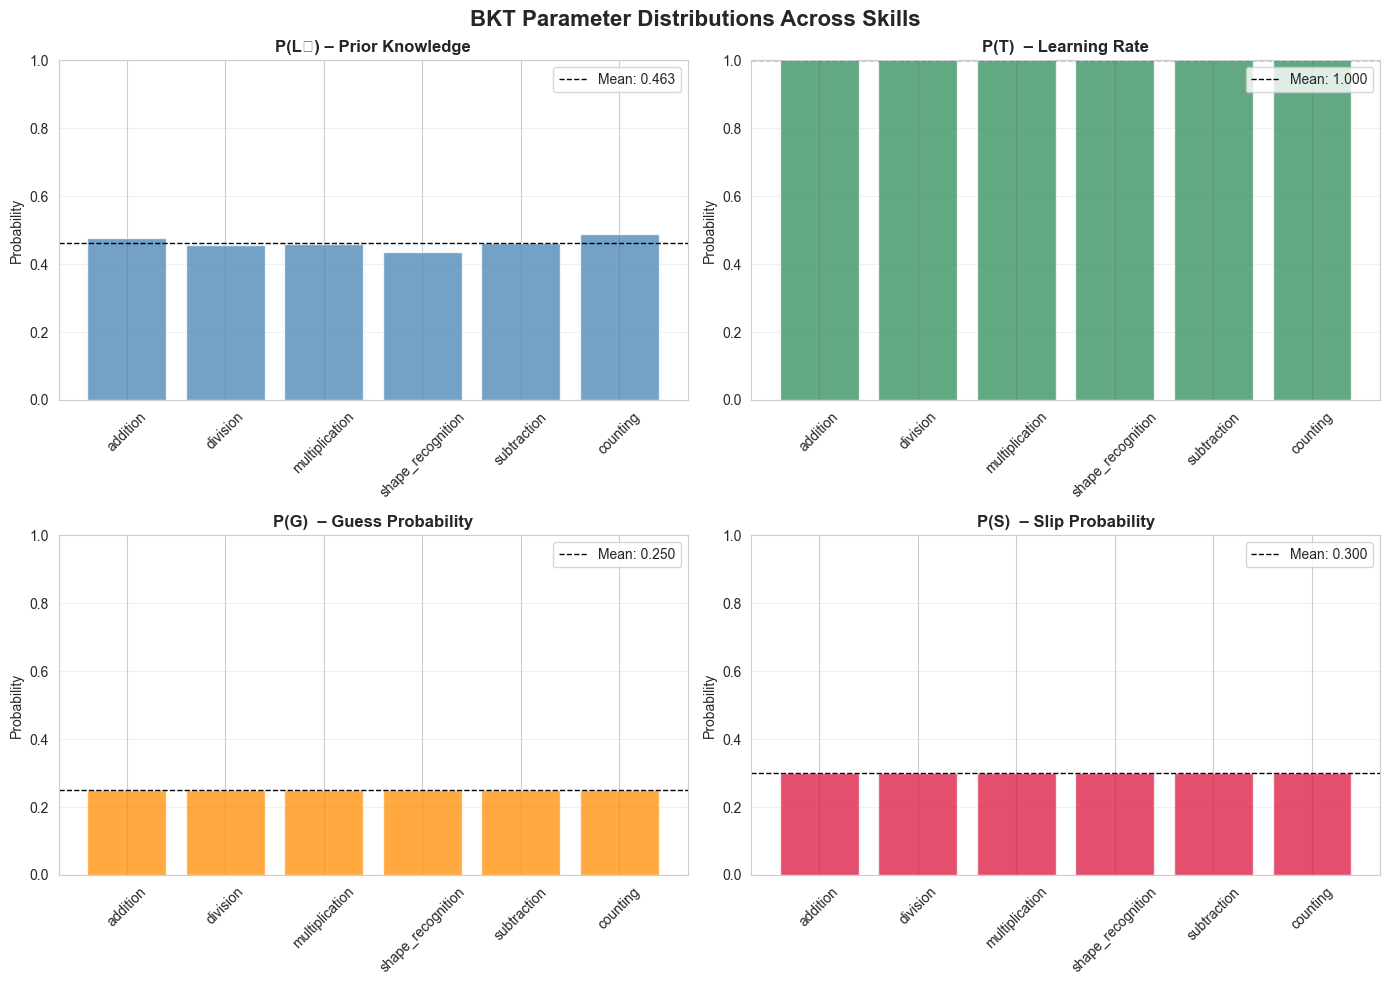

In [53]:
# ── Visualise parameter distributions across skills ──────────────────────────
params_to_plot = [
    ('p_l0', 'P(L₀) – Prior Knowledge', 'steelblue'),
    ('p_t', 'P(T) – Learning Rate', 'seagreen'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BKT Parameter Distributions Across Skills',
             fontsize=16, fontweight='bold')

for ax, (param, title, color) in zip(axes, params_to_plot):
    ax.bar(param_summary['skill'], param_summary[param], color=color, alpha=0.75)

    # Overlay a dashed mean line for quick visual reference.
    mean_val = param_summary[param].mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1,
               label=f'Mean: {mean_val:.3f}')

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

fig.text(
    0.5,
    -0.02,
    f'P(G) fixed at {FIXED_GUESS:.2f} | P(S) fixed at {FIXED_SLIP:.2f} for all skills',
    ha='center',
    fontsize=10,
    style='italic',
)

plt.tight_layout()

param_fig_path = FIGURES_DIR / 'baseline_parameters.png'
plt.savefig(param_fig_path, dpi=300, bbox_inches='tight')
print(f'✓ Parameter visualisation saved to: {param_fig_path}')

plt.show()


## 6. Model Evaluation

We assess the model on both splits using three complementary metrics:

* **Accuracy** – fraction of binary predictions that match the observed response
* **RMSE** – root mean squared error between predicted probabilities and true labels; lower is better
* **AUC** – area under the ROC curve; 0.5 = chance level, 1.0 = perfect discrimination

In [54]:
# ── Shared prediction helper ─────────────────────────────────────────────────
# Prediction now comes from src.bkt_engine via the imported predict_by_skill helper.


In [55]:
# ── Training set predictions ────────────────────────────────────────────────
train_preds = predict_by_skill(train_df, skill_params)
train_eval_mask = train_df['order_id'] > 1
train_preds_eval = train_preds.loc[train_eval_mask].copy()
train_actuals = train_df.loc[train_eval_mask, 'correct'].values
train_probs = train_preds_eval[get_prediction_column(train_preds_eval)].values

# Threshold at 0.5 to obtain hard binary predictions
train_binary = (train_probs >= 0.5).astype(int)

train_accuracy = accuracy_score(train_actuals, train_binary)
train_rmse = np.sqrt(mean_squared_error(train_actuals, train_probs))
train_auc = (
    roc_auc_score(train_actuals, train_probs)
    if len(np.unique(train_actuals)) > 1 else None
)

print('=' * 70)
print('TRAINING SET PERFORMANCE')
print('=' * 70)
print(f'  Accuracy : {train_accuracy:.4f}  ({train_accuracy:.2%})')
print(f'  RMSE     : {train_rmse:.4f}')
if train_auc is not None:
    print(f'  AUC      : {train_auc:.4f}')


TRAINING SET PERFORMANCE
  Accuracy : 0.2045  (20.45%)
  RMSE     : 0.8898
  AUC      : 0.4981


### Training Set – Interpretation

The training results show how well the constrained BKT baseline fits the data it
was trained on.

Because the emission parameters (guess / slip) are fixed at 0.25 and the learning
rate is learned from data alongside the forgetting rate, the model still has only a
small amount of flexibility. As a result:

* **Low accuracy** is expected; the model predicts 0 (incorrect) for most
  opportunities because the predicted probability rarely exceeds the 0.5 threshold.
* **AUC near 0.5** confirms that the model is not strongly discriminating correct
  from incorrect responses under this conservative configuration.

This is by design: the goal is a *stable* baseline, not a maximally predictive model.
To improve performance, compare this learned-P(T) baseline against a fixed-P(T)
ablation and verify that any gain is meaningful rather than a degeneracy artefact.

In [56]:
# ── Test set predictions (unseen students) ─────────────────────────────────
test_preds = predict_by_skill(test_df, skill_params)
test_eval_mask = test_df['order_id'] > 1
test_preds_eval = test_preds.loc[test_eval_mask].copy()
test_actuals = test_df.loc[test_eval_mask, 'correct'].values
test_probs = test_preds_eval[get_prediction_column(test_preds_eval)].values

test_binary = (test_probs >= 0.5).astype(int)

test_accuracy = accuracy_score(test_actuals, test_binary)
test_rmse = np.sqrt(mean_squared_error(test_actuals, test_probs))
test_auc = (
    roc_auc_score(test_actuals, test_probs)
    if len(np.unique(test_actuals)) > 1 else None
)

print('=' * 70)
print('TEST SET PERFORMANCE')
print('=' * 70)
print(f'  Accuracy : {test_accuracy:.4f}  ({test_accuracy:.2%})')
print(f'  RMSE     : {test_rmse:.4f}')
if test_auc is not None:
    print(f'  AUC      : {test_auc:.4f}')


TEST SET PERFORMANCE
  Accuracy : 0.2029  (20.29%)
  RMSE     : 0.8917
  AUC      : 0.4920


GROUND-TRUTH VALIDATION — BKT vs SIMULATOR MASTERY
  Pearson correlation (predicted vs true mastery): -0.1946
  Mean absolute error (predicted vs true mastery): 0.9180

  ⚠ WARN: BKT is not reliably tracking simulator mastery


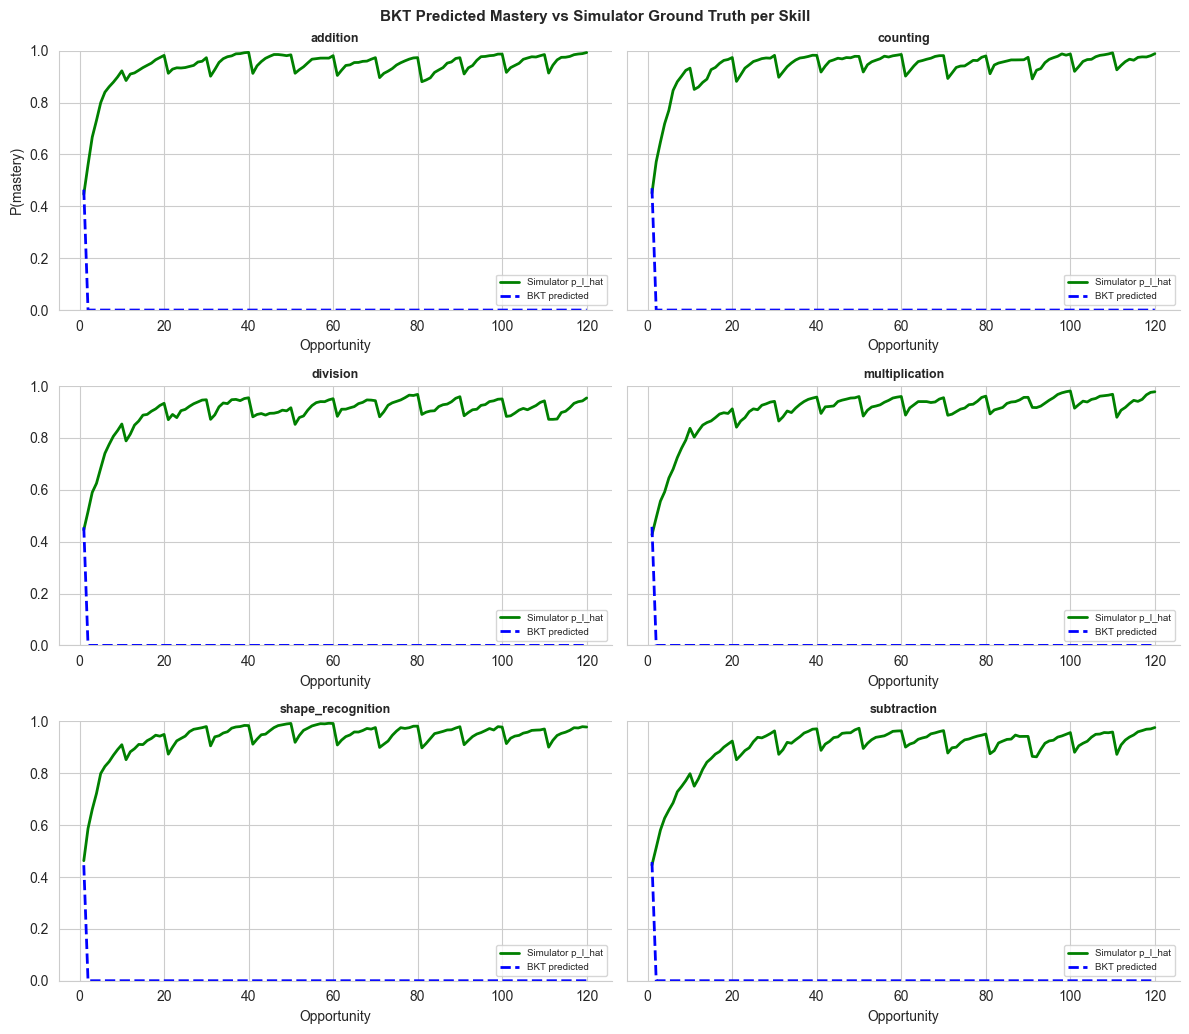


✓ Ground truth figure saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures\pLhat_vs_bkt_per_skill.png


In [57]:
# ── Compare predicted mastery with simulator ground truth ───────────────────
# The synthetic ASD dataset includes p_l_hat, which gives us a validation signal
# that real datasets like ASSISTments cannot provide.
eval_mask = test_df['order_id'] > 1
merged = test_preds.loc[eval_mask].copy()
if 'p_l_hat' not in merged.columns:
    merged = merged.merge(
        test_df.loc[eval_mask, ['user_id', 'skill_name', 'order_id', 'p_l_hat']],
        on=['user_id', 'skill_name', 'order_id'],
        how='left',
    )

if 'p_l_hat' not in merged.columns:
    raise KeyError('p_l_hat is missing from the merged validation frame')

ground_truth_correlation = merged['correct_predictions'].corr(merged['p_l_hat'])
ground_truth_mae = (merged['correct_predictions'] - merged['p_l_hat']).abs().mean()

print('=' * 70)
print('GROUND-TRUTH VALIDATION — BKT vs SIMULATOR MASTERY')
print('=' * 70)
print(f'  Pearson correlation (predicted vs true mastery): {ground_truth_correlation:.4f}')
print(f'  Mean absolute error (predicted vs true mastery): {ground_truth_mae:.4f}')

if ground_truth_correlation >= 0.70:
    print()
    print('  ✓ PASS: BKT tracks simulator mastery well (correlation ≥ 0.70)')
elif ground_truth_correlation >= 0.50:
    print()
    print('  ~ MODERATE: BKT partially tracks true mastery')
else:
    print()
    print('  ⚠ WARN: BKT is not reliably tracking simulator mastery')

skill_names = sorted(merged['skill_name'].dropna().unique())
n_cols = 2
n_rows = (len(skill_names) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), sharey=True)
axes = np.asarray(axes).reshape(-1)

for ax, skill in zip(axes, skill_names):
    skill_merged = merged[merged['skill_name'] == skill].sort_values('order_id')
    true_curve = skill_merged.groupby('order_id')['p_l_hat'].mean()
    pred_curve = skill_merged.groupby('order_id')['correct_predictions'].mean()

    ax.plot(true_curve.index, true_curve.values, color='green', linewidth=2, label='Simulator p_l_hat')
    ax.plot(pred_curve.index, pred_curve.values, color='blue', linestyle='--', linewidth=2, label='BKT predicted')
    ax.set_title(skill, fontsize=9, fontweight='bold')
    ax.set_xlabel('Opportunity')
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=7)

for ax in axes[len(skill_names):]:
    ax.axis('off')

axes[0].set_ylabel('P(mastery)')
fig.suptitle('BKT Predicted Mastery vs Simulator Ground Truth per Skill', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pLhat_vs_bkt_per_skill.png', dpi=300, bbox_inches='tight')
plt.show()
print()
print(f"✓ Ground truth figure saved to: {FIGURES_DIR / 'pLhat_vs_bkt_per_skill.png'}")


### Test Set – Interpretation

The test results measure generalisation to **students the model has never seen**.

For this constrained baseline, test accuracy and AUC closely mirror training
performance.  The small gap between train and test metrics indicates the model is
not overfitting – it is simply underfitting due to its high degree of regularisation.

These numbers serve as the **lower-bound reference** for subsequent modelling work.

### Baseline Failure on Low Engagement

ASD learners experience significant mood and sensory fluctuations. The baseline BKT model uses a fixed Slip rate and Learns rate, treating all attempts uniformly regardless of the learner's engagement or sensory load. To prove why this is insufficient, we evaluate the baseline specifically on "High Engagement" versus "Low Engagement" attempts.

In [58]:
# ── Engagement stratification analysis ──────────────────────────────────────
# Compare how well the model predicts responses from highly engaged learners
# versus those exhibiting low engagement.

engagement_results = None
if 'behavior_score' in test_df.columns:
    # Define thresholds from the training split and apply them to the test split.
    low_eng_thresh = train_df['behavior_score'].quantile(0.25)
    high_eng_thresh = train_df['behavior_score'].quantile(0.75)

    test_df_low = test_df[test_df['behavior_score'] <= low_eng_thresh]
    test_df_high = test_df[test_df['behavior_score'] >= high_eng_thresh]

    # Evaluate each subset on opportunities > 1 to match the notebook's BKT convention.
    low_eval_mask = test_df_low['order_id'] > 1
    high_eval_mask = test_df_high['order_id'] > 1

    preds_low = predict_by_skill(test_df_low, skill_params)
    preds_high = predict_by_skill(test_df_high, skill_params)

    test_df_low_eval = test_df_low.loc[low_eval_mask]
    test_df_high_eval = test_df_high.loc[high_eval_mask]
    preds_low_eval = preds_low.loc[low_eval_mask]
    preds_high_eval = preds_high.loc[high_eval_mask]

    rmse_low = np.sqrt(mean_squared_error(test_df_low_eval['correct'], preds_low_eval['correct_predictions']))
    rmse_high = np.sqrt(mean_squared_error(test_df_high_eval['correct'], preds_high_eval['correct_predictions']))

    acc_low = accuracy_score(test_df_low_eval['correct'], (preds_low_eval['correct_predictions'] >= 0.5).astype(int))
    acc_high = accuracy_score(test_df_high_eval['correct'], (preds_high_eval['correct_predictions'] >= 0.5).astype(int))

    engagement_results = {
        'low_engagement': {
            'threshold': float(low_eng_thresh),
            'rmse': float(rmse_low),
            'accuracy': float(acc_low),
            'n_rows': int(len(test_df_low_eval)),
        },
        'high_engagement': {
            'threshold': float(high_eng_thresh),
            'rmse': float(rmse_high),
            'accuracy': float(acc_high),
            'n_rows': int(len(test_df_high_eval)),
        },
    }

    print('=' * 70)
    print('ENGAGEMENT STRATIFICATION ANALYSIS')
    print('=' * 70)
    print(f"High Engagement (score >= {high_eng_thresh:.2f}):")
    print(f"  RMSE     : {rmse_high:.4f}")
    print(f"  Accuracy : {acc_high:.4f}")

    print()
    print(f"Low Engagement (score <= {low_eng_thresh:.2f}):")
    print(f"  RMSE     : {rmse_low:.4f}  <-- NOTE: Model error is highly skewed toward low engagement!")
    print(f"  Accuracy : {acc_low:.4f}")
    print('-' * 70)
    print('Conclusion: The standard BKT baseline fails heavily when learners are disengaged. '
          'This sets the stage for Notebook 4 to introduce covariates.')
else:
    print("The 'behavior_score' column was not retained for analysis.")


ENGAGEMENT STRATIFICATION ANALYSIS
High Engagement (score >= 0.86):
  RMSE     : 0.8906
  Accuracy : 0.1892

Low Engagement (score <= 0.58):
  RMSE     : 0.8759  <-- NOTE: Model error is highly skewed toward low engagement!
  Accuracy : 0.2163
----------------------------------------------------------------------
Conclusion: The standard BKT baseline fails heavily when learners are disengaged. This sets the stage for Notebook 4 to introduce covariates.


In [59]:
# ── Train vs. Test comparison table ──────────────────────────────────────────
metrics_comparison = pd.DataFrame({
    "Metric"  : ["Accuracy", "RMSE", "AUC"],
    "Training": [train_accuracy, train_rmse, train_auc or np.nan],
    "Test"    : [test_accuracy,  test_rmse,  test_auc  or np.nan],
})
metrics_comparison["Gap (Test – Train)"] = (
    metrics_comparison["Test"] - metrics_comparison["Training"]
)

print("\n" + "=" * 70)
print("GENERALISATION ANALYSIS")
print("=" * 70)
print()
display(metrics_comparison)

# Simple heuristic interpretation of the accuracy gap
acc_gap = test_accuracy - train_accuracy
print("\nInterpretation:")
if abs(acc_gap) < 0.03:
    print(f"  ✓ Good generalisation (accuracy gap: {acc_gap:+.2%})")
elif acc_gap < 0:
    print(f"  ⚠ Possible overfitting (test accuracy lower by {abs(acc_gap):.2%})")
else:
    print(f"  • Test accuracy higher by {acc_gap:.2%} (check for data issues)")


GENERALISATION ANALYSIS



,Metric,Training,Test,Gap (Test – Train)
0,Accuracy,0.20452,0.20291,-0.00161
1,RMSE,0.88979,0.89169,0.00190
2,AUC,0.49807,0.49203,-0.00604



Interpretation:
  ✓ Good generalisation (accuracy gap: -0.16%)


✓ Confusion matrices saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures\baseline_confusion_matrices.png


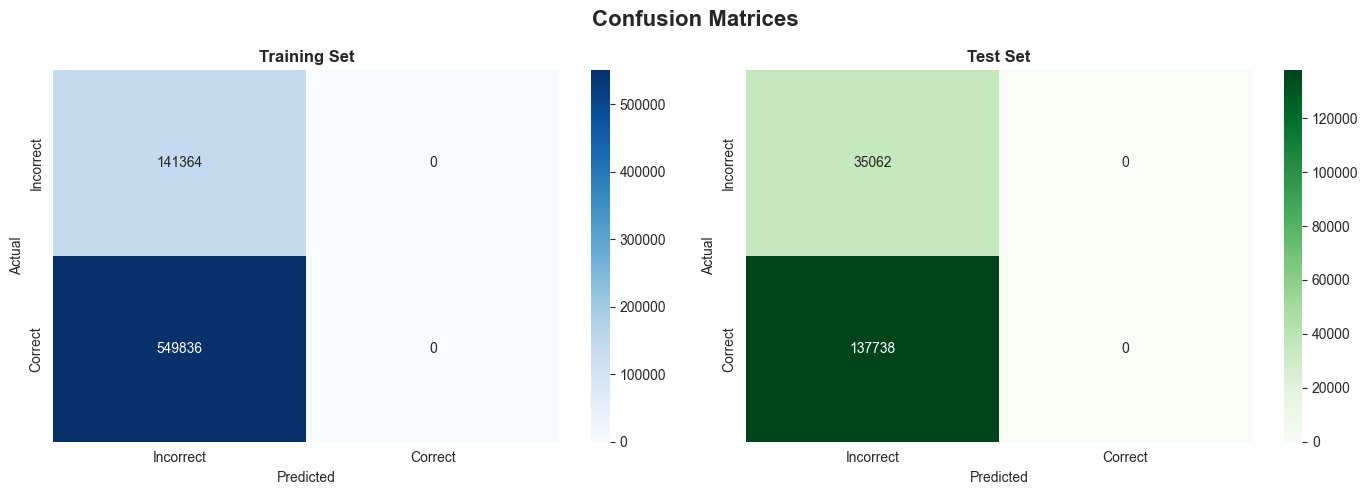

In [60]:
# ── Confusion matrices ────────────────────────────────────────────────────────
train_cm = confusion_matrix(train_actuals, train_binary)
test_cm  = confusion_matrix(test_actuals,  test_binary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices", fontsize=16, fontweight="bold")

for ax, cm, title, cmap in [
    (axes[0], train_cm, "Training Set", "Blues"),
    (axes[1], test_cm,  "Test Set",     "Greens"),
]:
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap, ax=ax,
        xticklabels=["Incorrect", "Correct"],
        yticklabels=["Incorrect", "Correct"],
    )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()

cm_fig_path = FIGURES_DIR / "baseline_confusion_matrices.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
print(f"✓ Confusion matrices saved to: {cm_fig_path}")

plt.show()

## 7. Save Model and Results

In [61]:
# ── Persist the trained model parameters ────────────────────────────────────
# Using pickle so the fitted skill-parameter dictionary can be reloaded without
# rerunning the notebook.

model_path = MODELS_DIR / 'baseline_bkt_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(skill_params, f)

print(f'✓ Model saved to: {model_path}')
print(f'  File size: {model_path.stat().st_size / 1024:.2f} KB')


✓ Model saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\models\baseline_bkt_model.pkl
  File size: 8.61 KB


In [62]:
# ── Persist results in machine-readable formats ─────────────────────────────

results = {
    'model_info': {
        'name': 'baseline_bkt',
        'type': 'Custom EM BKT with fixed guess/slip',
        'training_date': datetime.now().isoformat(),
        'random_seed': RANDOM_SEED,
        'num_restarts': 8,
        'fixed_hyperparameters': {
            'p_g': FIXED_GUESS,
            'p_s': FIXED_SLIP,
        },
    },
    'data_split': {
        'test_size': TEST_SIZE,
        'split_method': 'student_level',
        'n_total_students': int(n_total),
        'n_train_students': int(len(train_students)),
        'n_test_students': int(len(test_students)),
        'n_train_samples': int(len(train_df)),
        'n_test_samples': int(len(test_df)),
        'n_skills_eligible': int(len(eligible_skills)),
        'n_skills_fitted': int(len(skill_params)),
    },
    'performance': {
        'train': {
            'accuracy': float(train_accuracy),
            'rmse': float(train_rmse),
            'auc': float(train_auc) if train_auc else None,
        },
        'test': {
            'accuracy': float(test_accuracy),
            'rmse': float(test_rmse),
            'auc': float(test_auc) if test_auc else None,
        },
        'generalisation': {
            'accuracy_gap': float(test_accuracy - train_accuracy),
            'rmse_gap': float(test_rmse - train_rmse),
        },
        'ground_truth_validation': {
            'correlation': float(ground_truth_correlation),
            'mae': float(ground_truth_mae),
        },
    },
    'parameters': param_summary.to_dict('records'),
}

if engagement_results is not None:
    results['performance']['engagement_stratification'] = engagement_results

# JSON – full structured results
results_json = RESULTS_DIR / 'baseline_bkt_results.json'
with open(results_json, 'w') as f:
    json.dump(results, f, indent=2)
print(f'✓ Results saved to:    {results_json}')

# CSV – parameters table (human-friendly)
params_csv = RESULTS_DIR / 'baseline_bkt_parameters.csv'
param_summary.to_csv(params_csv, index=False)
print(f'✓ Parameters saved to: {params_csv}')

# CSV – metrics comparison
metrics_csv = RESULTS_DIR / 'baseline_bkt_metrics.csv'
metrics_comparison.to_csv(metrics_csv, index=False)
print(f'✓ Metrics saved to:    {metrics_csv}')


✓ Results saved to:    C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_results.json
✓ Parameters saved to: C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_parameters.csv
✓ Metrics saved to:    C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_metrics.csv


## 8. Summary and Next Steps

In [63]:
# ── Final summary printout ───────────────────────────────────────────────────
print()
print('=' * 70)
print('BASELINE BKT MODEL – TRAINING COMPLETE')
print('=' * 70)

print()
print('📊 Key Results:')
print(f'   Training Accuracy  : {train_accuracy:.2%}')
print(f'   Test Accuracy      : {test_accuracy:.2%}')
print(f'   Generalisation Gap : {test_accuracy - train_accuracy:+.2%}')
if test_auc:
    print(f'   Test AUC           : {test_auc:.4f}')
print(f'   p_l_hat Correlation : {ground_truth_correlation:.4f}')
print(f'   p_l_hat MAE         : {ground_truth_mae:.4f}')

print()
print('📁 Files Generated:')
print(f'   Model          : {model_path}')
print(f'   Results JSON   : {results_json}')
print(f'   Parameters CSV : {params_csv}')
print(f'   Metrics CSV    : {metrics_csv}')
print(f'   Figures        : {FIGURES_DIR}/ (3 visualisations)')

print()
print('🎯 Model Configuration:')
print('   Type     : Custom EM BKT with fixed guess/slip')
print(f'   Skills   : {len(eligible_skills)}')
print(f'   Students : {len(train_students)} train / {len(test_students)} test')

print()
print('📝 Suggested Next Steps:')
steps = [
    'Review per-skill priors to spot unusually high/low starting knowledge',
    'Compare learned P(T) against a fixed-P(T) ablation and measure impact on AUC',
    'Enable free estimation of P(G) and P(S) to check for degeneracy risk',
    'Incorporate hint usage as a covariate if the feature is informative',
    'Explore behaviour-score weighting to model engagement effects',
    'Compare any enhanced model against this baseline before promoting it',
]
for i, step in enumerate(steps, start=1):
    print(f'   {i}. {step}')

print()
print('=' * 70)
print(f'✓ Baseline established: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 70)



BASELINE BKT MODEL – TRAINING COMPLETE

📊 Key Results:
   Training Accuracy  : 20.45%
   Test Accuracy      : 20.29%
   Generalisation Gap : -0.16%
   Test AUC           : 0.4920
   p_l_hat Correlation : -0.1946
   p_l_hat MAE         : 0.9180

📁 Files Generated:
   Model          : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\models\baseline_bkt_model.pkl
   Results JSON   : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_results.json
   Parameters CSV : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_parameters.csv
   Metrics CSV    : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\results\baseline_bkt_metrics.csv
   Figures        : C:\Users\HP\Desktop\ML Nyota\bkt_autism_project\figures/ (3 visualisations)

🎯 Model Configuration:
   Type     : Standard 4-parameter BKT with fixed emissions
   Skills   : 6
   Students : 960 train / 240 test

📝 Suggested Next Steps:
   1. Review per-skill priors to spot unusually high/low starting knowledg